# Bộ phân loại ý định: ML cổ điển đấu với LLM

Phân loại tin nhắn khách hàng vào 5 ý định — `pricing` (hỏi giá), `complaint` (khiếu nại), `cancellation` (hủy gói), `tech_support` (hỗ trợ kỹ thuật), `other` (khác) — và so sánh:

| | Cách |
|---|---|
| A | TF-IDF (word + char n-gram) + logistic regression |
| B | Embedding `text-embedding-3-small` + logistic regression |
| C | Embedding + XGBoost |
| D | LLM zero-shot (`gpt-4o-mini`) |

Sau đó thử **chiến lược kết hợp**: model rẻ trả lời khi tự tin, còn lại chuyển cho LLM.

> Notebook chạy lại được **không cần API key**: embedding, dự đoán LLM và latency API đã được cache trong `data/cache/`. Model A/B/C được train lại ngay trong notebook.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix

from intent_router import experiments as ex
from intent_router.config import CACHE, DATA, EMBED_MODEL, LABELS, LLM_MODEL, cost_usd
from intent_router.embed import embed_texts
from intent_router.llm import load_cache

pd.set_option("display.max_colwidth", 120)
PER = 100_000

## 1. Dữ liệu

- **300 tin nhắn gán nhãn tay** (`data/seed_raw.tsv`) theo [hướng dẫn gán nhãn](../data/LABELING_GUIDE.md) — có dấu, không dấu, teencode, Vietglish, và các ca khó.
- **1.700 tin nhắn sinh bằng `gpt-4o-mini`** (đa dạng văn phong, persona, ~20% ca khó), rồi **gán nhãn độc lập bằng `gpt-4o`** theo cùng hướng dẫn.
- `cancellation` là lớp hiếm (~10%) → dùng `class_weight="balanced"` / sample weight và chia stratified.

In [2]:
df = ex.load_data()
report = json.loads((DATA / "dataset_report.json").read_text())
pd.crosstab(df.label, df.split, margins=True).loc[LABELS + ["All"], ["train", "val", "test", "All"]]

split,train,val,test,All
label,,,,
pricing,303,65,65,433
complaint,288,61,62,411
cancellation,146,32,31,209
tech_support,386,82,83,551
other,277,60,59,396
All,1400,300,300,2000


### Kiểm tra chất lượng nhãn LLM

1. **Annotator LLM vs nhãn người** trên 300 tin seed.
2. **Kiểm tra mẫu**: 100 tin LLM-gán-nhãn chọn ngẫu nhiên, người review lại (`data/audit_sample.csv`). Các nhãn người sửa được ghi đè vào dataset.

In [3]:
sa, au = report["seed_agreement"], report["audit"]
print(f"Annotator vs người (300 seed): accuracy = {sa['accuracy']:.1%}, Cohen's kappa = {sa['cohen_kappa']:.3f}")
print(f"Kiểm tra mẫu (100 tin LLM gán):  đồng thuận = {au['agreement']:.0%}")
print(f"Nhãn annotator trùng ý định lúc sinh: {report['generation_intent_agreement']:.1%}")
pd.DataFrame(sa["disagreements"] + [{"text": d["text"], "human": d["human_label"], "llm": d["llm_label"]} for d in au["disagreements"]])

Annotator vs người (300 seed): accuracy = 99.0%, Cohen's kappa = 0.987
Kiểm tra mẫu (100 tin LLM gán):  đồng thuận = 95%
Nhãn annotator trùng ý định lúc sinh: 89.5%


,text,human,llm
0,"Báo cáo bị lệch số so với dữ liệu thực tế, kiểm tra giúp mình",tech_support,complaint
1,Không thấy dữ liệu tuần trước trên dashboard,tech_support,complaint
2,tìm kiếm không ra kết quả dù task có tồn tại,tech_support,complaint
3,"Nhân viên văn phòng báo cắt dịch vụ mà không thấy thông báo gì, rất khó chịu.",complaint,cancellation
4,Cảm giác như một số tính năng còn phức tạp hơn mình nghĩ. Có must-have nào không?,tech_support,other
5,Nếu mình gia hạn mà ko sử dụng thì có được hoàn lại ko?,pricing,cancellation
6,Các bạn có bí kíp nào dùng tốt hơn không?,tech_support,other
7,Làm ơn cho mình biết là có diễn đàn hỗ trợ trực tuyến không? Mình thích tham gia với các anh chị em khác. Thank you!,other,tech_support


## 2. Train A / B / C, dự đoán D

Train trên `train`, báo cáo trên `test`. Cross-validation 5-fold trên `train+val`.

In [4]:
tr, te = (df[df.split == s].reset_index(drop=True) for s in ("train", "test"))
trva = df[df.split != "test"].reset_index(drop=True)
E = dict(zip(df.text, embed_texts(df.text.tolist())))   # from cache
emb = lambda part: np.stack([E[t] for t in part.text])
inputs = {
    "A": {"tr": tr.text.tolist(), "te": te.text.tolist(), "trva": trva.text.tolist()},
    "B": {"tr": emb(tr), "te": emb(te), "trva": emb(trva)},
}
inputs["C"] = inputs["B"]

models, probas, preds, cv, oof = {}, {}, {}, {}, {}
for k in "ABC":
    cv[k], oof[k] = ex.cross_validate(k, inputs[k]["trva"], trva.label.values)
    models[k] = ex.FACTORIES[k]().fit(inputs[k]["tr"], tr.label.values)
    probas[k] = ex.proba_in_label_order(models[k], inputs[k]["te"])
    preds[k] = np.array(LABELS)[probas[k].argmax(1)]
    print(f"{ex.NAMES[k]:<36} CV macro-F1 = {np.mean(cv[k]):.3f} ± {np.std(cv[k]):.3f}")

zs = load_cache(CACHE / f"zeroshot_{LLM_MODEL}.jsonl")
preds["D"] = np.array([zs[t]["label"] for t in te.text])

A. TF-IDF + logistic regression      CV macro-F1 = 0.886 ± 0.011


B. Embedding + logistic regression   CV macro-F1 = 0.902 ± 0.016


C. Embedding + XGBoost               CV macro-F1 = 0.879 ± 0.020


### Latency & chi phí

- **A**: đo thời gian predict từng tin nhắn một trên máy local.
- **B, C**: 1 lần gọi embedding API cho mỗi tin (đo thật, cache trong `embed_latency_*.jsonl`) + thời gian classifier.
- **D**: 1 lần gọi `gpt-4o-mini` mỗi tin (đo thật).
- Chi phí /100k tin = token trung bình thực tế × 100k × giá niêm yết (`config.PRICES`).

In [5]:
emb_lat = load_cache(CACHE / f"embed_latency_{EMBED_MODEL}.jsonl")
emb_ms = np.array([emb_lat[t]["latency_ms"] for t in te.text])
llm_ms = np.array([zs[t]["latency_ms"] for t in te.text])
emb_cost = cost_usd(EMBED_MODEL, np.mean([emb_lat[t]["input_tokens"] for t in te.text]) * PER)
llm_cost = cost_usd(LLM_MODEL, np.mean([zs[t]["input_tokens"] for t in te.text]) * PER,
                    np.mean([zs[t]["output_tokens"] for t in te.text]) * PER)

ms = {"A": ex.per_message_ms(lambda x: models["A"].predict_proba([x]), inputs["A"]["te"], repeats=3)}
for k in "BC":
    ms[k] = ex.per_message_ms(lambda x, m=models[k]: m.predict_proba(x[None]), inputs[k]["te"], repeats=3) + emb_ms
ms["D"] = llm_ms
cost = {"A": 0.0, "B": emb_cost, "C": emb_cost, "D": llm_cost}

rows = []
for k in "ABCD":
    lo, hi = ex.bootstrap_ci(te.label, preds[k])
    rows.append({
        "Cách": ex.NAMES[k],
        "Macro-F1 test": round(ex.macro_f1(te.label, preds[k]), 3),
        "95% CI (bootstrap)": f"{lo:.2f}–{hi:.2f}",
        "Macro-F1 CV": f"{np.mean(cv[k]):.3f} ± {np.std(cv[k]):.3f}" if k in cv else "—",
        "p50 (ms)": round(np.percentile(ms[k], 50), 1),
        "p95 (ms)": round(np.percentile(ms[k], 95), 1),
        "$/100k tin": round(cost[k], 2),
    })
comparison = pd.DataFrame(rows).set_index("Cách")
comparison

,Macro-F1 test,95% CI (bootstrap),Macro-F1 CV,p50 (ms),p95 (ms),$/100k tin
Cách,,,,,,
A. TF-IDF + logistic regression,0.906,0.87–0.94,0.886 ± 0.011,0.6,0.7,0.00
B. Embedding + logistic regression,0.882,0.84–0.92,0.902 ± 0.016,235.6,317.8,0.06
C. Embedding + XGBoost,0.896,0.86–0.93,0.879 ± 0.020,235.8,318.1,0.06
D. LLM zero-shot,0.943,0.92–0.97,—,736.9,911.1,3.23


Đọc bảng:
- Khoảng tin cậy 95% của A/B/C **chồng lên nhau** trên 300 tin test → không nên kết luận A thắng B chỉ từ một lần split. CV 5-fold (1.700 tin) ổn định hơn: B nhỉnh nhất trong nhóm rẻ.
- D tốt hơn rõ (~+4 điểm macro-F1), nhưng **chậm hơn ~1.000×** so với A và **đắt hơn ~50×** so với B.

## 3. Confusion matrix

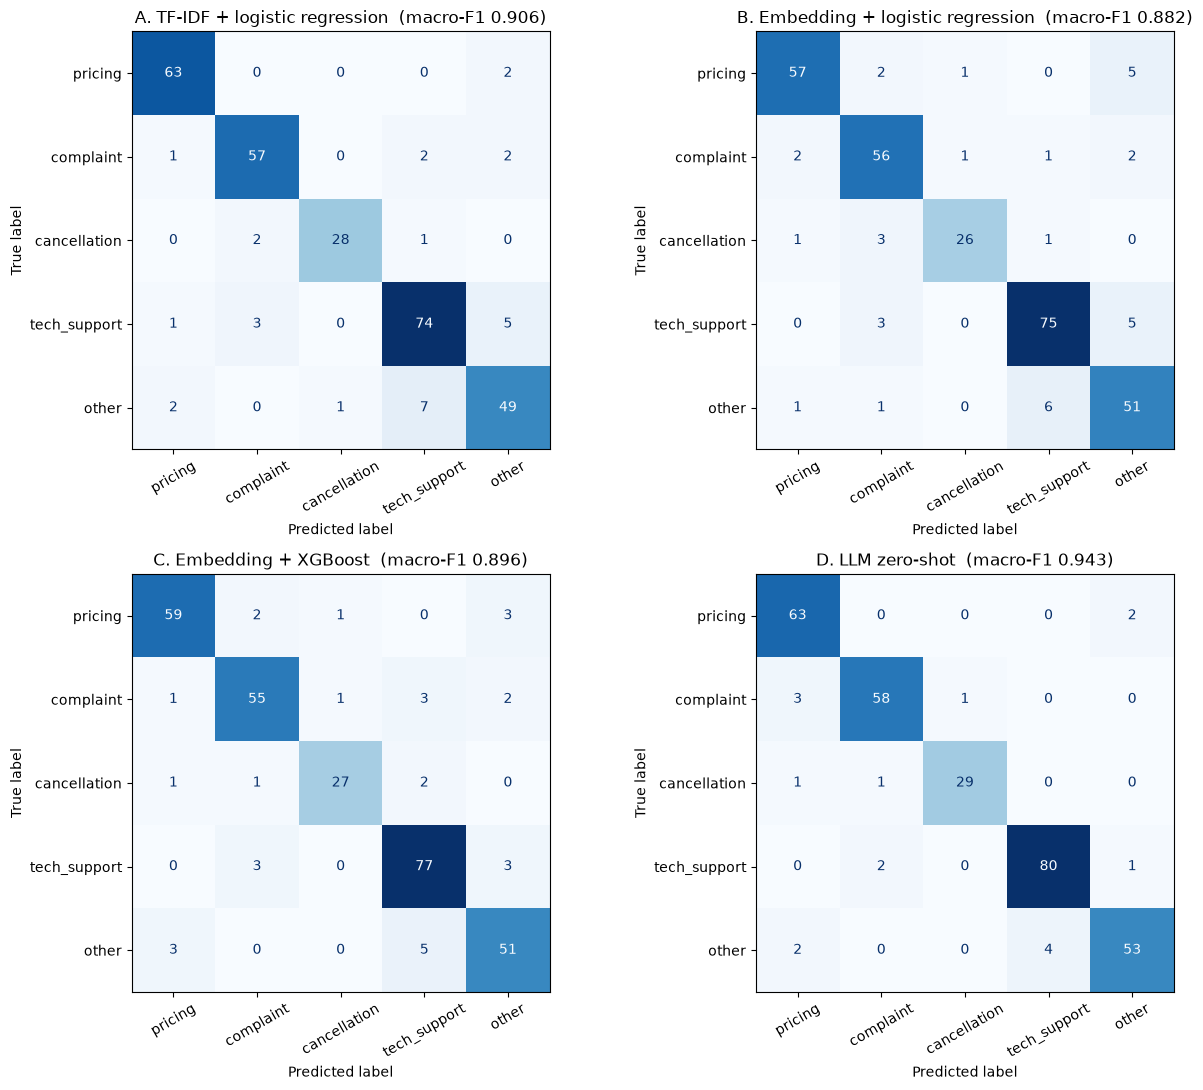

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
for ax, k in zip(axes.flat, "ABCD"):
    cm = confusion_matrix(te.label, preds[k], labels=LABELS)
    ConfusionMatrixDisplay(cm, display_labels=LABELS).plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=30)
    ax.set_title(f"{ex.NAMES[k]}  (macro-F1 {ex.macro_f1(te.label, preds[k]):.3f})")
fig.tight_layout()

In [7]:
pd.DataFrame({ex.NAMES[k]: {l: classification_report(te.label, preds[k], labels=LABELS, output_dict=True)[l]["f1-score"]
              for l in LABELS} for k in "ABCD"}).round(3)

,A. TF-IDF + logistic regression,B. Embedding + logistic regression,C. Embedding + XGBoost,D. LLM zero-shot
pricing,0.955,0.905,0.915,0.940
complaint,0.919,0.882,0.894,0.943
cancellation,0.933,0.881,0.900,0.951
tech_support,0.886,0.904,0.906,0.958
other,0.838,0.836,0.864,0.922


### Lớp hiếm: class weight có giúp không?

`cancellation` chiếm ~10%. Ablation bằng CV 5-fold trên train+val, so sánh **không weight** và **class weight balanced** ở hai mức:
- tỷ lệ tự nhiên (~10,5% trong train fold);
- ép hiếm hơn: chỉ giữ 25% số tin `cancellation` trong **train fold** (~2,9%), fold đánh giá giữ nguyên phân bố.

Kết quả đã tính sẵn bằng `scripts/rare_class_ablation.py` (không gọi API; mất vài phút vì XGBoost).

In [8]:
from intent_router.config import RESULTS
rare = pd.read_json(RESULTS / "rare_class_ablation.json")
rare.assign(method=rare.method.map(ex.NAMES), balanced=rare.balanced.map({True: "balanced", False: "không"})) \
    .set_index(["method", "rare_share_train", "balanced"]).drop(columns="keep_frac").round(3)

macro_f1  \
method                             rare_share_train balanced             
A. TF-IDF + logistic regression    0.028717         không        0.836   
                                                    balanced     0.863   
                                   0.104706         không        0.878   
                                                    balanced     0.886   
B. Embedding + logistic regression 0.028717         không        0.861   
                                                    balanced     0.897   
                                   0.104706         không        0.903   
                                                    balanced     0.902   
C. Embedding + XGBoost             0.028717         không        0.818   
                                                    balanced     0.839   
                                   0.104706         không        0.875   
                                                    balanced     0.879   

                                                              rare_precision  \
method                             rare_share_train balanced                   
A. TF-IDF + logistic regression    0.028717         không              1.000   
                                                    balanced           0.986   
                                   0.104706         không              0.968   
                                                    balanced           0.959   
B. Embedding + logistic regression 0.028717         không              0.992   
                                                    balanced           0.976   
                                   0.104706         không              0.971   
                                                    balanced           0.932   
C. Embedding + XGBoost             0.028717         không              0.990   
                                                    balanced           0.990   
                                   0.104706         không              0.954   
                                                    balanced           0.952   

                                                              rare_recall  \
method                             rare_share_train balanced                
A. TF-IDF + logistic regression    0.028717         không           0.572   
                                                    balanced        0.724   
                                   0.104706         không           0.837   
                                                    balanced        0.876   
B. Embedding + logistic regression 0.028717         không           0.640   
                                                    balanced        0.842   
                                   0.104706         không           0.887   
                                                    balanced        0.898   
C. Embedding + XGBoost             0.028717         không           0.466   
                                                    balanced        0.544   
                                   0.104706         không           0.786   
                                                    balanced        0.814   

                                                              rare_f1  \
method                             rare_share_train balanced            
A. TF-IDF + logistic regression    0.028717         không       0.725   
                                                    balanced    0.832   
                                   0.104706         không       0.896   
                                                    balanced    0.914   
B. Embedding + logistic regression 0.028717         không       0.772   
                                                    balanced    0.901   
                                   0.104706         không       0.925   
                                                    balanced    0.912   
C. Embedding + XGBoost             0.028717         không       0.629   
                      

- Ở **~10%**, weight gần như không đổi gì (macro-F1 ±0,01); với B còn giảm nhẹ precision. Lớp chưa đủ hiếm để model bỏ qua.
- Ở **~2,9%**, không weight thì model **bỏ sót gần nửa số tin hủy gói** (recall A 0,57, B 0,64, C 0,47). Bật `balanced` kéo recall lên 0,72 / 0,84 / 0,54 và F1 lớp hiếm +7 đến +13 điểm, trong khi precision gần như giữ nguyên.
- XGBoost chịu lớp hiếm kém nhất kể cả khi có weight → thêm lý do chọn mô hình tuyến tính.
- Với routing, bỏ sót `cancellation` là lỗi đắt (khách muốn hủy không được xử lý), nên giữ `class_weight="balanced"` là mặc định an toàn.

## 4. Phân tích lỗi theo cặp lớp

In [9]:
pairs = pd.DataFrame([
    {"cách": k, "thật → đoán": f"{a} → {b}", "số lỗi": n}
    for k in "ABCD" for a, b, n in ex.confused_pairs(te.label, preds[k], top=10)
]).pivot_table(index="thật → đoán", columns="cách", values="số lỗi", fill_value=0)
pairs.assign(tổng=pairs.sum(axis=1)).sort_values("tổng", ascending=False).head(10)

cách,A,B,C,D,tổng
thật → đoán,,,,,
other → tech_support,7.0,6.0,5.0,4.0,22.0
tech_support → other,5.0,5.0,3.0,1.0,14.0
pricing → other,2.0,5.0,3.0,2.0,12.0
tech_support → complaint,3.0,3.0,3.0,2.0,11.0
other → pricing,2.0,0.0,3.0,2.0,7.0
cancellation → complaint,2.0,3.0,0.0,1.0,6.0
complaint → other,2.0,2.0,2.0,0.0,6.0
complaint → pricing,1.0,2.0,0.0,3.0,6.0
complaint → tech_support,2.0,0.0,3.0,0.0,5.0


In [10]:
def examples(true, pred, k, n=5):
    return te.text[(te.label == true) & (preds[k] == pred)].head(n).tolist()

for k, (a, b) in [("A", ("other", "tech_support")), ("A", ("tech_support", "other")),
                  ("B", ("cancellation", "complaint")), ("D", ("complaint", "pricing"))]:
    print(f"\n[{k}] {a} → {b}")
    for t in examples(a, b, k):
        print("   -", t)


[A] other → tech_support
   - Có bản tiếng Anh của tài liệu điều khoản sử dụng không?
   - Có tính năng nào có thể đổi mã dự án không?
   - Mình thấy giao diện của phần mềm rất bắt mắt, không biết có thể tùy chỉnh nó được không?
   - Hey, có người nhận chat không?
   - what's the update on the project?

[A] tech_support → other
   - App bên mình vừa update giờ nó k còn load dc!
   - Stuck on loading page for too long now!
   - giao diện mới thấy khó dùng ghê, có ai giúp mk không?
   - Trời ơi, sao ban ngày cũng lag nhỉ?
   - Các bạn có tính năng quản lý thời gian không?

[B] cancellation → complaint
   - Mong ad xem lại vụ bị lỗi hủy gói mà ko cho! Thang này bị thu 2 lần mệt ghê!
   - Tôi đã liên hệ để hủy gói nhưng giờ vẫn thấy bị trừ tiền, rất bất tiện.
   - Hơi thất vọng, thôi hủy luôn cho đơn giản

[D] complaint → pricing
   - Tại sao phí dịch vụ lại tăng mà không có thông báo gửi trước cho tôi vậy?
   - Tại sao tháng này bị trừ tiền nhiều hơn tháng trước thế?
   - Mình đang xài g

In [11]:
wrong_all = te[(preds["A"] != te.label) & (preds["B"] != te.label) & (preds["D"] != te.label)]
print(f"A sai {(preds['A'] != te.label).sum()} tin, trong đó D đúng {((preds['A'] != te.label) & (preds['D'] == te.label)).sum()}")
print(f"D sai {(preds['D'] != te.label).sum()} tin, trong đó A đúng {((preds['D'] != te.label) & (preds['A'] == te.label)).sum()}")
wrong_all[["text", "label"]].assign(A=preds["A"][wrong_all.index], D=preds["D"][wrong_all.index])

A sai 29 tin, trong đó D đúng 24
D sai 17 tin, trong đó A đúng 12


,text,label,A,D
56,"Thời gian sử dụng của từng gói không rõ ràng lắm, phối hợp kịp không?",other,pricing,pricing
109,Mong ad xem lại vụ bị lỗi hủy gói mà ko cho! Thang này bị thu 2 lần mệt ghê!,cancellation,complaint,complaint
235,Có tính năng nào có thể đổi mã dự án không?,other,tech_support,tech_support
265,"Uh, cho tôi hỏi, bài viết trên blog có tính phí không?",other,pricing,pricing
272,"Chúc các bạn luôn phát triển, không biết trong tương lai sẽ có bản dùng thử cho gói Enterprise không?",pricing,other,other


Nhận xét (chi tiết trong [blog](../docs/blog-khi-nao-khong-can-llm.md)):

1. **`other` ↔ `tech_support`** là cặp nhầm nhiều nhất ở mọi cách. Câu hỏi "có tính năng X không?" hay "có ai trực không?" nằm ở ranh giới định nghĩa — đây phần lớn là lỗi *định nghĩa nhãn*, không phải lỗi model.
2. **`tech_support` ↔ `complaint`**: báo lỗi kèm cảm xúc ("Mỗi lần dùng là có lỗi, không thể yên tâm làm việc!"). Bag-of-words thấy từ "lỗi" → `tech_support`; LLM đọc được giọng điệu.
3. **`cancellation` → `complaint`** (B: 3, A: 2): tin vừa phàn nàn vừa đòi hủy ("Hơi thất vọng, thôi hủy luôn cho đơn giản"). Quy tắc nói có ý định hủy thì là `cancellation`, nhưng phần cảm xúc tiêu cực chiếm phần lớn câu nên kéo embedding về `complaint`. Đây là lỗi đắt nhất khi route: khách muốn hủy bị đưa vào hàng đợi khiếu nại.
4. **D: `complaint` → `pricing`**: "Tại sao tháng này bị trừ tiền nhiều hơn?" — LLM zero-shot thấy chủ đề tiền và chọn `pricing`, trong khi quy tắc phân xử ghi rõ bị tính sai → `complaint`. Few-shot/quy tắc trong prompt sẽ sửa được.
5. 5 tin mà cả A, B, D cùng sai phần lớn là nhãn mập mờ → trần chất lượng thực tế bị giới hạn bởi nhãn, không phải model.

## 5. Chiến lược kết hợp: model rẻ khi tự tin, còn lại → LLM

Quy tắc: nếu `max p > ngưỡng` thì dùng nhãn model rẻ, ngược lại gọi LLM.

**Chọn ngưỡng không dùng test**: quét ngưỡng trên dự đoán *out-of-fold* của CV 5-fold trên train+val (1.700 tin — ổn định hơn nhiều so với 300 tin val), chọn **ngưỡng rẻ nhất mà macro-F1 ≥ LLM-only** trên cùng dữ liệu. Sau đó mới báo cáo trên test.

In [12]:
trva_llm = np.array([zs[t]["label"] for t in trva.text])
llm_only_cv = ex.macro_f1(trva.label, trva_llm)
rng = np.random.default_rng(0)
curves, chosen = {}, {}
for k in "AB":
    cv_curve = ex.hybrid_curve(oof[k], trva_llm, trva.label, cost[k], llm_cost,
                               rng.choice(ms[k], len(trva)), rng.choice(llm_ms, len(trva)))
    te_curve = ex.hybrid_curve(probas[k], preds["D"], te.label, cost[k], llm_cost, ms[k], llm_ms)
    chosen[k] = ex.pick_threshold(cv_curve, llm_only_cv)
    curves[k] = (cv_curve, te_curve)

print(f"LLM-only macro-F1 trên train+val: {llm_only_cv:.3f}")
pd.DataFrame([
    {"hybrid": f"{k} → D", "ngưỡng": t, **curves[k][1].set_index("threshold").loc[t].round(3).to_dict()}
    for k in "AB" for t in (chosen[k], 0.8)
]).rename(columns={"routed_pct": "% chuyển LLM", "macro_f1": "macro-F1 test", "cost_per_100k": "$/100k"})

LLM-only macro-F1 trên train+val: 0.947


,hybrid,ngưỡng,% chuyển LLM,macro-F1 test,$/100k,p95_ms,p50_ms
0,A → D,0.72,24.667,0.931,0.798,791.530,0.589
1,A → D,0.80,32.667,0.940,1.057,807.865,0.599
2,B → D,0.81,26.333,0.945,0.909,1062.204,273.664
3,B → D,0.80,26.000,0.945,0.898,1062.204,272.866


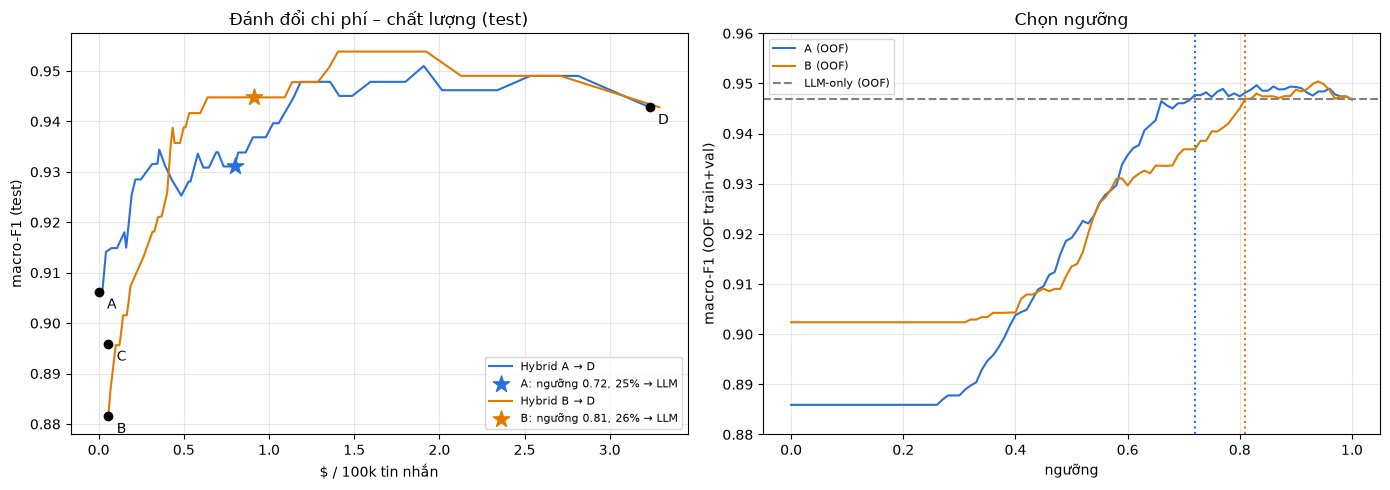

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {"A": "#2a6fdb", "B": "#e07b00"}
for k in "AB":
    cv_curve, te_curve = curves[k]
    axes[0].plot(te_curve.cost_per_100k, te_curve.macro_f1, color=colors[k], label=f"Hybrid {k} → D")
    pt = te_curve.set_index("threshold").loc[chosen[k]]
    axes[0].scatter(pt.cost_per_100k, pt.macro_f1, marker="*", s=150, color=colors[k], zorder=5,
                    label=f"{k}: ngưỡng {chosen[k]:.2f}, {pt.routed_pct:.0f}% → LLM")
    axes[1].plot(cv_curve.threshold, cv_curve.macro_f1, color=colors[k], label=f"{k} (OOF)")
    axes[1].axvline(chosen[k], color=colors[k], ls=":")
for k in "ABCD":
    f1 = ex.macro_f1(te.label, preds[k])
    axes[0].scatter(cost[k], f1, color="black", zorder=6); axes[0].annotate(k, (cost[k], f1), xytext=(6, -12), textcoords="offset points")
axes[1].axhline(llm_only_cv, color="gray", ls="--", label="LLM-only (OOF)")
axes[0].set(xlabel="$ / 100k tin nhắn", ylabel="macro-F1 (test)", title="Đánh đổi chi phí – chất lượng (test)")
axes[1].set(xlabel="ngưỡng", ylabel="macro-F1 (OOF train+val)", title="Chọn ngưỡng", ylim=(0.88, 0.96))
for ax in axes: ax.grid(alpha=.3); ax.legend(fontsize=8)
fig.tight_layout()

### Kết luận

- **A → D, ngưỡng 0,72**: ~75% tin nhắn xử lý local dưới 1 ms, chỉ ~25% gọi LLM → **giảm ~75% chi phí** so với LLM-only, macro-F1 test 0,931 (LLM-only 0,943, nằm trong khoảng tin cậy). p50 vẫn < 1 ms.
- **B → D, ngưỡng 0,81**: macro-F1 0,945 — **ngang LLM-only** với ~28% chi phí, nhưng mọi tin đều trả thêm ~240 ms cho embedding.
- Ngưỡng 0,8 trong đề bài gần với ngưỡng B tự chọn (0,81); với A thì 0,72 đã đủ đạt mức LLM trên OOF.

Router cho dự án #3: `intent_router.router.IntentRouter` (A → D, ngưỡng 0,72 lưu trong `models/tfidf_lr.joblib`; model triển khai được fit lại trên train+val).